<a href="https://colab.research.google.com/github/mohith-4/FIFA_2026_Analysis/blob/main/Final_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

players = pd.read_excel("/content/data1_DS.xlsx")

print(players.head())
print(players.shape)
print(players.columns)

   Rk           Player Pos         Squad  Age  Born  90s  Gls▼  Sh  SoT  SoT%  \
0   1    Kylian Mbappé  FW     fr France   27  1998  7.7    10  41   23  56.1   
1   2     Lionel Messi  FW  ar Argentina   38  1987  8.2     8  35   18  51.4   
2   3  Jude Bellingham  MF   eng England   22  2003  6.8     7  19   13  68.4   
3   4   Erling Haaland  FW     no Norway   25  2000  5.2     7  20   13  65.0   
4   5  Ousmane Dembélé  MF     fr France   29  1997  6.6     6  20   10  50.0   

   Sh/90  SoT/90  G/Sh  G/SoT  PK  PKatt  Matches  
0   5.31    2.98  0.24   0.43   1      2  Matches  
1   4.26    2.19  0.23   0.44   0      2  Matches  
2   2.79    1.91  0.37   0.54   0      0  Matches  
3   3.87    2.52  0.35   0.54   0      0  Matches  
4   3.04    1.52  0.30   0.60   0      0  Matches  
(499, 18)
Index(['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Gls▼', 'Sh',
       'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK', 'PKatt',
       'Matches'],
      dtype='object')


In [ ]:
print(players.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rk       499 non-null    int64  
 1   Player   499 non-null    object 
 2   Pos      499 non-null    object 
 3   Squad    499 non-null    object 
 4   Age      499 non-null    int64  
 5   Born     499 non-null    int64  
 6   90s      499 non-null    float64
 7   Gls▼     499 non-null    int64  
 8   Sh       499 non-null    int64  
 9   SoT      499 non-null    int64  
 10  SoT%     363 non-null    float64
 11  Sh/90    499 non-null    float64
 12  SoT/90   499 non-null    float64
 13  G/Sh     363 non-null    float64
 14  G/SoT    264 non-null    float64
 15  PK       499 non-null    int64  
 16  PKatt    499 non-null    int64  
 17  Matches  499 non-null    object 
dtypes: float64(6), int64(8), object(4)
memory usage: 70.3+ KB
None


In [ ]:
print("Number of duplicate rows:", players.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df = players.rename(columns={'90s': 'Minutes', 'Gls▼': 'Goals', 'Sh': 'Shots', 'SoT': 'Shots_on_Target'})

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rk               499 non-null    int64  
 1   Player           499 non-null    object 
 2   Pos              499 non-null    object 
 3   Squad            499 non-null    object 
 4   Age              499 non-null    int64  
 5   Born             499 non-null    int64  
 6   Minutes          499 non-null    float64
 7   Goals            499 non-null    int64  
 8   Shots            499 non-null    int64  
 9   Shots_on_Target  499 non-null    int64  
 10  SoT%             363 non-null    float64
 11  Sh/90            499 non-null    float64
 12  SoT/90           499 non-null    float64
 13  G/Sh             363 non-null    float64
 14  G/SoT            264 non-null    float64
 15  PK               499 non-null    int64  
 16  PKatt            499 non-null    int64  
 17  Matches         

In [ ]:
df.isnull().sum()

,0
Rk,0
Player,0
Pos,0
Squad,0
Age,0
Born,0
Minutes,0
Goals,0
Shots,0
Shots_on_Target,0


In [ ]:
df = df[[ "Player", "Squad","Pos","Minutes","Shots","Shots_on_Target","Goals"]]

In [ ]:
df['Minutes'] = df['Minutes'] * 90

In [ ]:
df["Minutes"] = pd.to_numeric(df["Minutes"], errors="coerce")
df["Shots"] = pd.to_numeric(df["Shots"], errors="coerce")
df["Shots_on_Target"] = pd.to_numeric(
    df["Shots_on_Target"], errors="coerce"
)
df["Goals"] = pd.to_numeric(df["Goals"], errors="coerce")

In [ ]:
df = df.dropna(subset=["Minutes","Shots","Shots_on_Target","Goals"])

In [ ]:
df = df[(df["Minutes"] > 0) &
    (df["Shots"] >= 0) &
    (df["Shots_on_Target"] >= 0) &
    (df["Goals"] >= 0) &
    (df["Shots_on_Target"] <= df["Shots"])
].copy()

In [ ]:
df["Shots_per_90"] = (df["Shots"] / df["Minutes"]) * 90

In [ ]:
df["Shooting_Accuracy"] = (df["Shots_on_Target"] / df["Shots"]) * 100

In [ ]:
df["Goals_per_90"] = ( df["Goals"] /df["Minutes"]) * 90

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485 entries, 0 to 498
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player             485 non-null    object 
 1   Squad              485 non-null    object 
 2   Pos                485 non-null    object 
 3   Minutes            485 non-null    float64
 4   Shots              485 non-null    int64  
 5   Shots_on_Target    485 non-null    int64  
 6   Goals              485 non-null    int64  
 7   Shots_per_90       485 non-null    float64
 8   Shooting_Accuracy  361 non-null    float64
 9   Goals_per_90       485 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 41.7+ KB


In [ ]:
df = df[df["Shots"] > 0].copy()


print("\nNumber of players who played:")
print(len(df))


Number of players who played:
361


In [ ]:
df.Pos.unique()

array(['FW', 'MF', 'FW,MF', 'MF,FW', 'DF', 'DF,MF', 'MF,DF'], dtype=object)

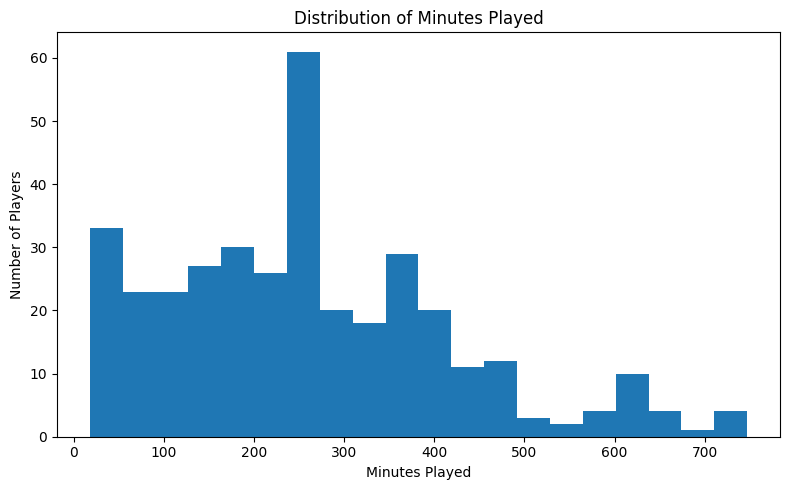

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["Minutes"],bins=20)

plt.title("Distribution of Minutes Played")
plt.xlabel("Minutes Played")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

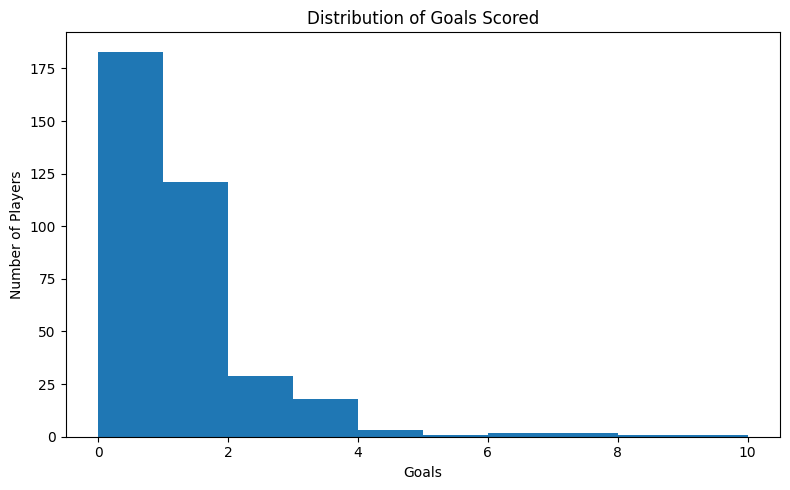

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["Goals"],bins=10)

plt.title("Distribution of Goals Scored")
plt.xlabel("Goals")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

In [ ]:
df["Main_Position"] = (df["Pos"].str.split(",").str[0].str.strip())
print("\nPlayer positions:")
print(df["Main_Position"].value_counts())



Player positions:
Main_Position
MF    174
FW    101
DF     86
Name: count, dtype: int64


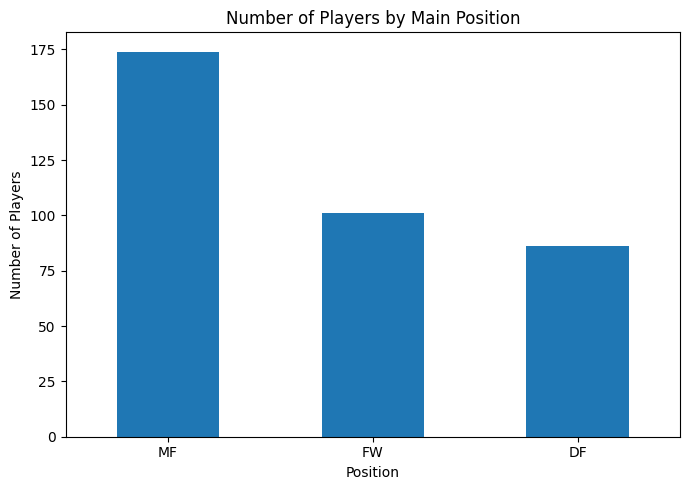

In [ ]:
# Number of players by position

position_counts = df["Main_Position"].value_counts()
plt.figure(figsize=(7, 5))
position_counts.plot(kind="bar")
plt.title("Number of Players by Main Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
sample = df.sample(n=200,random_state=42).copy()
print("Sample size:")
print(len(sample))

print("Sample position distribution:")
print(sample["Main_Position"].value_counts())


Sample size:
200

Sample position distribution:
Main_Position
MF    103
FW     52
DF     45
Name: count, dtype: int64


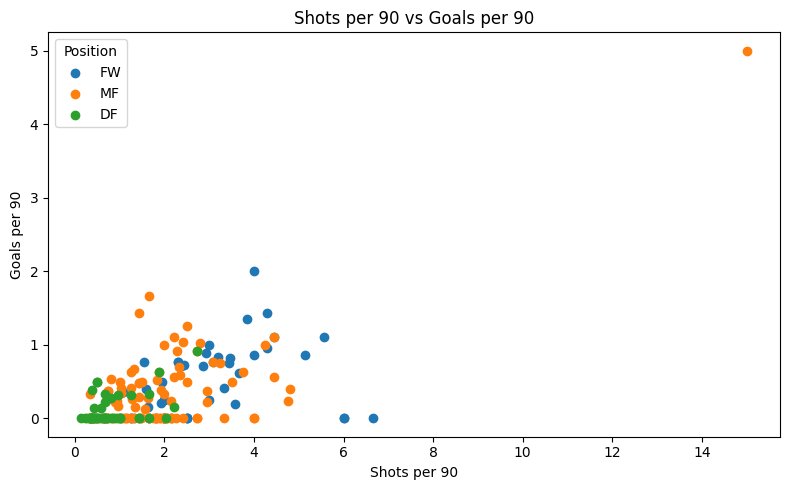

In [ ]:
plt.figure(figsize=(8, 5))

for position in ['FW', 'MF', 'DF']:

    position_data = sample[sample['Main_Position'] == position]
    plt.scatter(position_data['Shots_per_90'],position_data['Goals_per_90'],label=position)

plt.title('Shots per 90 vs Goals per 90')
plt.xlabel('Shots per 90')
plt.ylabel('Goals per 90')
plt.legend(title='Position')

plt.tight_layout()
plt.show()

In [ ]:
# Mean
sample.groupby("Main_Position")[[ "Shots_per_90", "Shooting_Accuracy", "Goals_per_90"]].mean()

,Shots_per_90,Shooting_Accuracy,Goals_per_90
Main_Position,,,
DF,0.815947,32.190476,0.114860
FW,2.698393,42.027165,0.444438
MF,1.906372,34.405802,0.339858


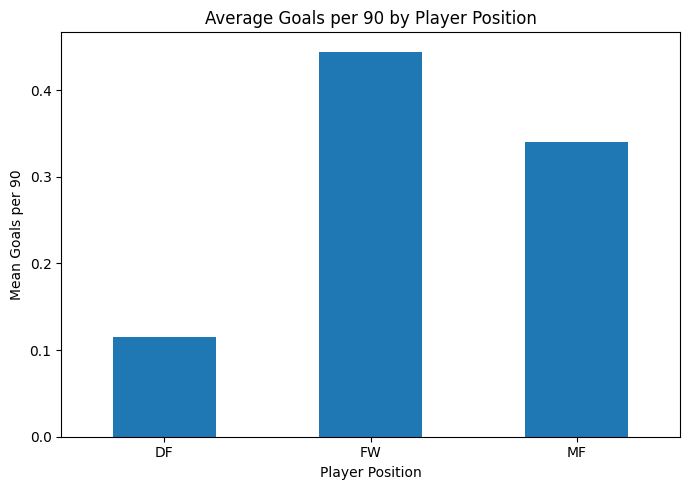

In [ ]:
mean_goals = sample.groupby( "Main_Position")["Goals_per_90"].mean()

plt.figure(figsize=(7, 5))
mean_goals.plot(kind="bar")
plt.title("Average Goals per 90 by Player Position")
plt.xlabel("Player Position")
plt.ylabel("Mean Goals per 90")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#Median

sample.groupby("Main_Position")[ ["Shots_per_90", "Shooting_Accuracy", "Goals_per_90"]].median()

,Shots_per_90,Shooting_Accuracy,Goals_per_90
Main_Position,,,
DF,0.666667,28.571429,0.000000
FW,2.409988,44.949495,0.303571
MF,1.666667,33.333333,0.161290


In [ ]:
#std

sample.groupby("Main_Position")[["Shots_per_90","Shooting_Accuracy","Goals_per_90"]].std()

,Shots_per_90,Shooting_Accuracy,Goals_per_90
Main_Position,,,
DF,0.580201,34.847253,0.207133
FW,1.472416,29.393640,0.475648
MF,1.675303,27.378764,0.596047


In [ ]:
summary = sample.groupby("Main_Position")[[ "Shots_per_90","Shooting_Accuracy","Goals_per_90"]].agg(
    ["count", "mean", "median", "std", "min", "max"])

print(summary)

              Shots_per_90                                                     \
                     count      mean    median       std       min        max   
Main_Position                                                                   
DF                      45  0.815947  0.666667  0.580201  0.149254   2.727273   
FW                      52  2.698393  2.409988  1.472416  0.476190   6.666667   
MF                     103  1.906372  1.666667  1.675303  0.322581  15.000000   

              Shooting_Accuracy                                               \
                          count       mean     median        std  min    max   
Main_Position                                                                  
DF                           45  32.190476  28.571429  34.847253  0.0  100.0   
FW                           52  42.027165  44.949495  29.393640  0.0  100.0   
MF                          103  34.405802  33.333333  27.378764  0.0  100.0   

              Goals_per_90      

In [ ]:
summary = sample.groupby("Main_Position").agg(
    Players=("Player", "count"),
    Mean_Shots_per_90=("Shots_per_90", "mean"),
    Mean_Accuracy=("Shooting_Accuracy", "mean"),
    Mean_Goals_per_90=("Goals_per_90", "mean"))

print(summary)

               Players  Mean_Shots_per_90  Mean_Accuracy  Mean_Goals_per_90
Main_Position                                                              
DF                  45           0.815947      32.190476           0.114860
FW                  52           2.698393      42.027165           0.444438
MF                 103           1.906372      34.405802           0.339858


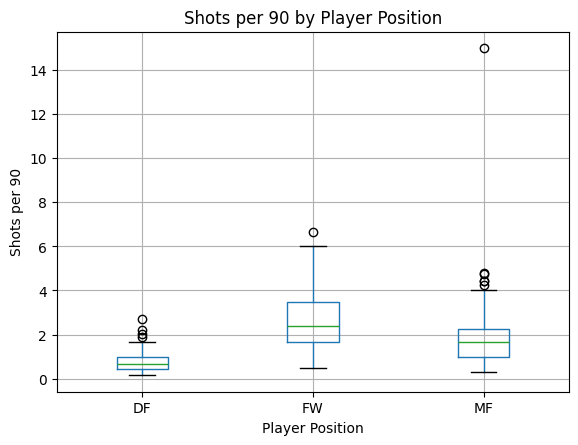

In [ ]:
sample.boxplot(column="Shots_per_90", by="Main_Position")
plt.title("Shots per 90 by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Shots per 90")
plt.show()

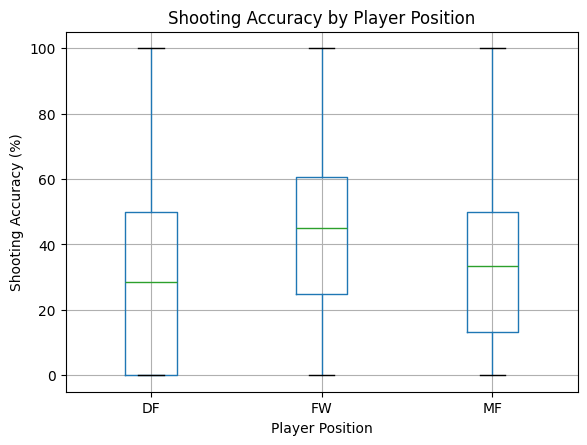

In [ ]:
sample.boxplot(column="Shooting_Accuracy",by="Main_Position")
plt.title("Shooting Accuracy by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Shooting Accuracy (%)")
plt.show()

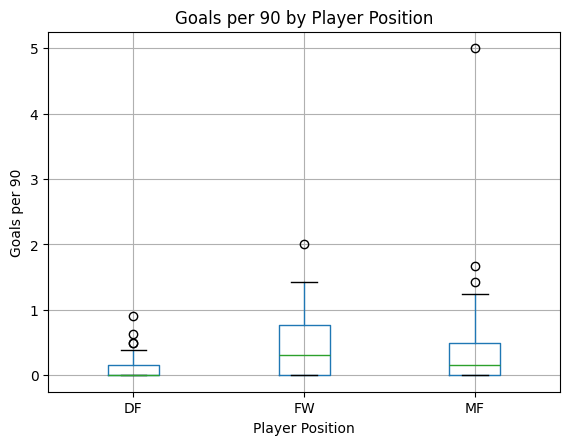

In [ ]:
sample.boxplot(column="Goals_per_90",by="Main_Position")
plt.title("Goals per 90 by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Goals per 90")
plt.show()

In [ ]:
## Z based COnf Interv

import math
import numpy as np
from scipy.stats import norm

def confidence_interval(values, confidence_level=0.95):
    n = len(values)
    mean = values.mean()
    standard_deviation = values.std()
    standard_error = (standard_deviation /math.sqrt(n) )
    z_star = norm.ppf(1 - (1 - confidence_level) / 2)
    margin_of_error = (z_star *standard_error)
    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return mean, lower , upper



In [ ]:
for position in ["FW", "MF", "DF"]:

    values = sample[sample["Main_Position"] == position]["Goals_per_90"]
    mean, lower, upper = confidence_interval(values)
    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


FW
Mean: 0.4444384334433416
95% CI: 0.3151582009130612 to 0.573718665973622
MF
Mean: 0.33985838728453416
95% CI: 0.22474927903352393 to 0.4549674955355444
DF
Mean: 0.11486029159041562
95% CI: 0.05434134377602165 to 0.1753792394048096


In [ ]:
# t-test

forwards = sample[sample["Main_Position"] == "FW"]["Goals_per_90"]

midfielders = sample[sample["Main_Position"] == "MF"]["Goals_per_90"]

test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)
print(test_result)

TtestResult(statistic=np.float64(1.1841337400751442), pvalue=np.float64(0.238611884823823), df=np.float64(124.72317541789809))


In [ ]:
for position in ["FW", "MF", "DF"]:

    values = sample[sample["Main_Position"] == position]["Shots_per_90"]

    mean, lower, upper = confidence_interval(values)
    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


FW
Mean: 2.698392596779777
95% CI: 2.2981927581663912 to 3.0985924353931624
MF
Mean: 1.9063722138795844
95% CI: 1.5828360874191667 to 2.2299083403400024
DF
Mean: 0.8159467113123213
95% CI: 0.6464270973673673 to 0.9854663252572754


In [ ]:
# t-test

forwards = sample[sample["Main_Position"] == "FW"]["Shots_per_90"]

midfielders = sample[sample["Main_Position"] == "MF"]["Shots_per_90"]

test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)
print(test_result)

TtestResult(statistic=np.float64(3.016451313426339), pvalue=np.float64(0.0031492744570305567), df=np.float64(114.90737246832126))


In [ ]:
for position in ["FW", "MF", "DF"]:

    values = sample[sample["Main_Position"] == position]["Shooting_Accuracy"]
    mean, lower, upper = confidence_interval(values)

    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


FW
Mean: 42.027165347851174
95% CI: 34.03802966426778 to 50.016301031434566
MF
Mean: 34.40580182389373
95% CI: 29.11838783817584 to 39.69321580961163
DF
Mean: 32.19047619047619
95% CI: 22.009008512161767 to 42.37194386879061


In [ ]:
# t-test

forwards = sample[sample["Main_Position"] == "FW"]["Shooting_Accuracy"]

midfielders = sample[sample["Main_Position"] == "MF"]["Shooting_Accuracy"]

test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)
print(test_result)

TtestResult(statistic=np.float64(1.5591918621525682), pvalue=np.float64(0.12223378933668926), df=np.float64(96.230759754453))


In [ ]:
print(sample[["Player","Main_Position","Minutes","Goals","Goals_per_90" ]].sort_values("Goals_per_90",ascending=False).head(15))

                  Player Main_Position  Minutes  Goals  Goals_per_90
165     Mattias Svanberg            MF     18.0      1      5.000000
68      Nadhir Benbouali            FW     45.0      1      2.000000
95      Hassan Al-Haydos            MF     54.0      1      1.666667
114           Jovo Lukić            FW     63.0      1      1.428571
111     Giovani Lo Celso            MF     63.0      1      1.428571
3         Erling Haaland            FW    468.0      7      1.346154
33          Habib Diarra            MF    144.0      2      1.250000
154  Alexis Saelemaekers            MF     81.0      1      1.111111
176      Gessime Yassine            MF     81.0      1      1.111111
78         Promise David            FW     81.0      1      1.111111
105       Saša Kalajdžić            FW     81.0      1      1.111111
19           Elijah Just            MF    261.0      3      1.034483
2        Jude Bellingham            MF    612.0      7      1.029412
9           Ismaila Sarr          

## Take Players with Min. of 90 minutes playing time


In [ ]:
analysis_data = sample[sample["Minutes"] >= 90].copy()

<Figure size 800x500 with 0 Axes>

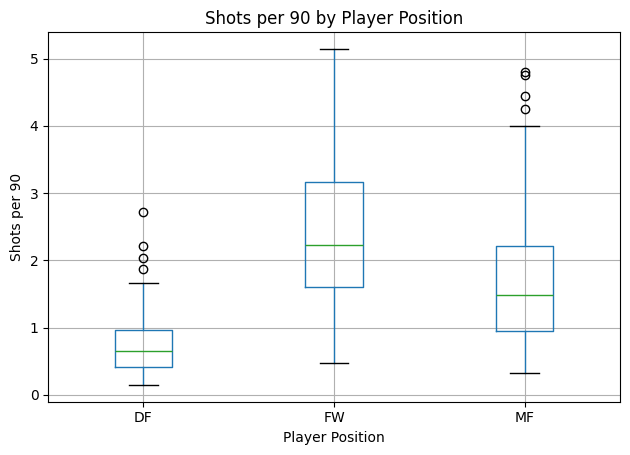

In [ ]:
plt.figure(figsize=(8, 5))

analysis_data.boxplot(column="Shots_per_90",by="Main_Position")

plt.title("Shots per 90 by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Shots per 90")

plt.tight_layout()
plt.show()

In [ ]:
print(
    analysis_data["Main_Position"].value_counts()
)

Main_Position
MF    94
DF    44
FW    38
Name: count, dtype: int64


In [ ]:
print(analysis_data.groupby("Main_Position")["Goals_per_90"].agg(["count", "mean", "median", "std", "min", "max"]))

               count      mean    median       std  min       max
Main_Position                                                    
DF                44  0.117471  0.000000  0.208778  0.0  0.909091
FW                38  0.459474  0.408333  0.377662  0.0  1.346154
MF                94  0.262638  0.155272  0.317295  0.0  1.250000


In [ ]:
for position in ["FW", "MF", "DF"]:

    values = analysis_data[analysis_data["Main_Position"] == position]["Goals_per_90"]
    mean, lower, upper = confidence_interval(values)
    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


FW
Mean: 0.4594738128489502
95% CI: 0.33939692804326216 to 0.5795506976546383
MF
Mean: 0.26263780396645414
95% CI: 0.19849514213983213 to 0.3267804657930762
DF
Mean: 0.11747075276292507
95% CI: 0.05578202876370766 to 0.17915947676214247


In [ ]:
# t-test

forwards = analysis_data[ analysis_data["Main_Position"] == "FW"]["Goals_per_90"]
midfielders = analysis_data[analysis_data["Main_Position"] == "MF"]["Goals_per_90"]

test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)
print(test_result)

TtestResult(statistic=np.float64(2.8338889834375327), pvalue=np.float64(0.006279240602635598), df=np.float64(59.21035942594415))


<Figure size 800x500 with 0 Axes>

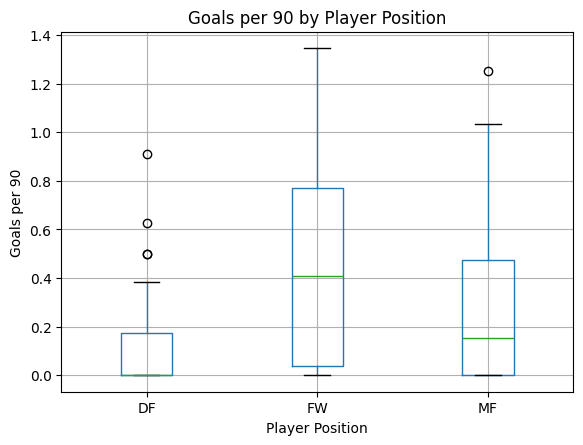

In [ ]:
plt.figure(figsize=(8, 5))

analysis_data.boxplot( column="Goals_per_90", by="Main_Position")

plt.title("Goals per 90 by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Goals per 90")
plt.show()

In [ ]:
for position in ["FW", "MF", "DF"]:

    values = analysis_data[ analysis_data["Main_Position"] == position]["Shots_per_90"]
    mean, lower, upper = confidence_interval(values)
    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


FW
Mean: 2.360457037197389
95% CI: 2.0006312790874436 to 2.7202827953073343
MF
Mean: 1.7084514177414092
95% CI: 1.5011041299703225 to 1.9157987055124959
DF
Mean: 0.8020234222837052
95% CI: 0.6308680397738228 to 0.9731788047935875


In [ ]:
# t-test

forwards = analysis_data[analysis_data["Main_Position"] == "FW"]["Shots_per_90"]
midfielders = analysis_data[analysis_data["Main_Position"] == "MF"]["Shots_per_90"]
test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)

print(test_result)

TtestResult(statistic=np.float64(3.0771298883511595), pvalue=np.float64(0.003093881291747587), df=np.float64(62.89291766047976))


In [ ]:
for position in ["FW", "MF", "DF"]:

    values = analysis_data[analysis_data["Main_Position"] == position]["Shooting_Accuracy"]

    mean, lower, upper = confidence_interval(values)
    print(position)
    print("Mean:", mean)
    print("95% CI:", lower, "to", upper)


  # t-test

forwards = analysis_data[analysis_data["Main_Position"] == "FW"]["Shooting_Accuracy"]

midfielders = analysis_data[analysis_data["Main_Position"] == "MF"]["Shooting_Accuracy"]
test_result = stats.ttest_ind(forwards,midfielders,equal_var=False)
print(test_result)

FW
Mean: 46.06348942337529
95% CI: 38.13641513103324 to 53.990563715717336
MF
Mean: 33.53330767228072
95% CI: 28.287858042989185 to 38.778757301572256
DF
Mean: 32.92207792207792
95% CI: 22.610334801572368 to 43.23382104258347
TtestResult(statistic=np.float64(2.5836493741150885), pvalue=np.float64(0.011832942367220208), df=np.float64(71.07439763065466))


<Figure size 800x500 with 0 Axes>

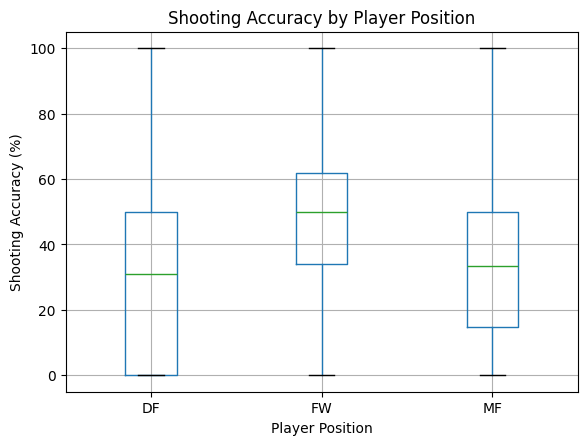

In [ ]:
plt.figure(figsize=(8, 5))

analysis_data.boxplot(column="Shooting_Accuracy",by="Main_Position")

plt.title("Shooting Accuracy by Player Position")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Shooting Accuracy (%)")
plt.show()

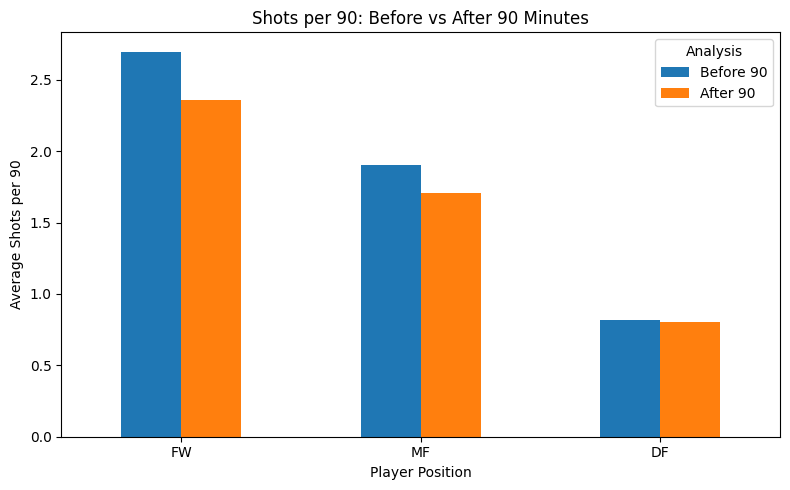

In [ ]:
shots_comparison = (sample.groupby('Main_Position')['Shots_per_90'].agg(['mean']).rename(columns={'mean': 'Before 90'}))
shots_after = (analysis_data.groupby('Main_Position')['Shots_per_90'].mean().rename('After 90'))

shots_comparison = shots_comparison.join(shots_after)
shots_comparison = shots_comparison.reindex(['FW', 'MF', 'DF'])
shots_comparison.plot( kind='bar', figsize=(8, 5))
plt.title('Shots per 90: Before vs After 90 Minutes')
plt.xlabel('Player Position')
plt.ylabel('Average Shots per 90')
plt.xticks(rotation=0)
plt.legend(title='Analysis')

plt.tight_layout()
plt.show()

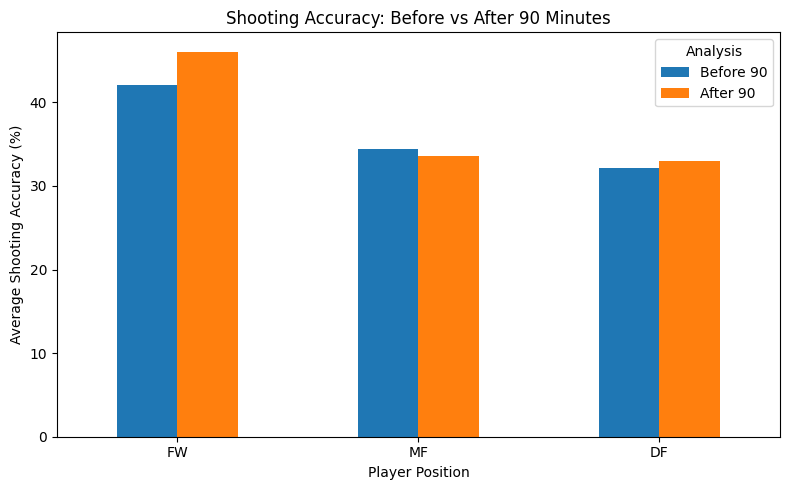

In [ ]:
accuracy_comparison = (sample.groupby('Main_Position')['Shooting_Accuracy'].mean().rename('Before 90').to_frame())

accuracy_after = (analysis_data.groupby('Main_Position')['Shooting_Accuracy'].mean().rename('After 90'))
accuracy_comparison = accuracy_comparison.join(accuracy_after)
accuracy_comparison = accuracy_comparison.reindex(['FW', 'MF', 'DF'])

accuracy_comparison.plot( kind='bar', figsize=(8, 5))

plt.title('Shooting Accuracy: Before vs After 90 Minutes')
plt.xlabel('Player Position')
plt.ylabel('Average Shooting Accuracy (%)')
plt.xticks(rotation=0)
plt.legend(title='Analysis')

plt.tight_layout()
plt.show()

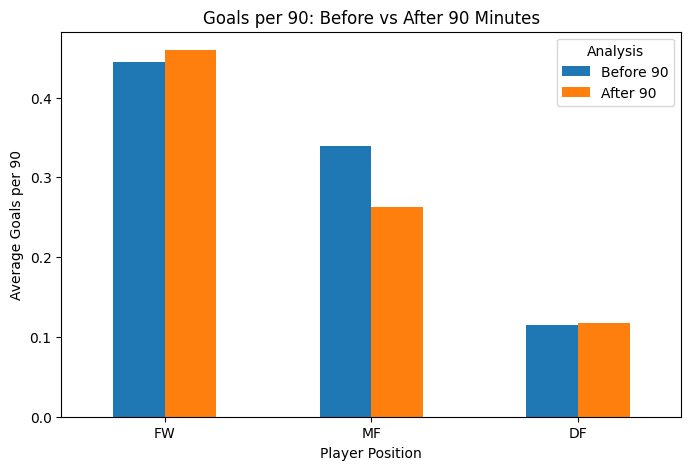

In [ ]:
goals_comparison = ( sample.groupby('Main_Position')['Goals_per_90'].mean().rename('Before 90').to_frame())

goals_after = (analysis_data.groupby('Main_Position')['Goals_per_90'].mean().rename('After 90'))

goals_comparison = goals_comparison.join(goals_after)
goals_comparison = goals_comparison.reindex(['FW', 'MF', 'DF'])

goals_comparison.plot(kind='bar',figsize=(8, 5))

plt.title('Goals per 90: Before vs After 90 Minutes')
plt.xlabel('Player Position')
plt.ylabel('Average Goals per 90')
plt.xticks(rotation=0)
plt.legend(title='Analysis')
plt.show()